# Agrega dados diários do GEE para mensais

- `Acesso aos dados`: [Sentinel-5P NRTI CO: Near Real-Time Carbon Monoxide](https://developers.google.com/earth-engine/datasets/catalog/COPERNICUS_S5P_NRTI_L3_CO)
- `Período dos dados`: 2018-11-22T12:00:13Z–2025-04-12T09:36:31Z
- `Resolução espacial`: 1113.2 metros
- `Resolução temporal`: diária
- `Código realizado por`: Enrique V. Mattos - 19/05/2024

# **1° Passo:** Preparando ambiente

In [1]:
# instalando bibliotecas
!pip install -q ultraplot cartopy salem rasterio

# iniciando GEE e instalando XEE (transforma dados do GEE para formato DataSet)
!pip install -q eemont xee
import ee, geemap
ee.Authenticate()
ee.Initialize(project='ee-enrique', opt_url='https://earthengine-highvolume.googleapis.com')

# importa bibliotecas
import numpy as np
import ultraplot as uplt
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import time
from zipfile import ZipFile
import salem
from datetime import datetime
import glob
import xarray as xr
import os
import cartopy.crs as ccrs
import warnings
warnings.filterwarnings('ignore')

"""
# monta drive
from google.colab import drive
drive.mount('/content/drive')

# caminho do drive
dir = '/content/drive/MyDrive/5_EXTENSAO/02_prefeitura_analise_periodo_chuvoso_2024_2025'

# leitura do shapefile do Brasil
shapefile_brasil = salem.read_shapefile('https://github.com/evmpython/shapefile/raw/main/brasil/BRAZIL.shp')

# leitura do shapefile com a biblioteca SALEM
url = 'https://github.com/evmpython/shapefile/raw/main/'
shp = salem.read_shapefile(f'{url}itajuba/itajuba.shp')
itajuba = salem.read_shapefile(f'{url}itajuba/itajuba.shp')
mg = salem.read_shapefile(f'{url}estado_MG/MG_UF_2019.shp')

# limites do Brasil
lonmin_BR, lonmax_BR, latmin_BR, latmax_BR = -75.0, -33.0, -35.0, 7.0

# limites de MG
lonmin_MG, lonmax_MG, latmin_MG, latmax_MG = -52., -39., -23., -14.
"""

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.5/13.5 MB 28.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 45.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.1/86.1 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 33.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 30.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.7/134.7 kB 4.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.7/224.7 kB 13.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 47.5 MB/s eta 0:00:00


/usr/local/lib/python3.11/dist-packages/ultraplot/__init__.py:77: UltraPlotWarning: Rebuilding font cache. This usually happens after installing or updating ultraplot.
  register_fonts(default=True)


"\n# monta drive\nfrom google.colab import drive\ndrive.mount('/content/drive')\n\n# caminho do drive\ndir = '/content/drive/MyDrive/5_EXTENSAO/02_prefeitura_analise_periodo_chuvoso_2024_2025'\n\n# leitura do shapefile do Brasil\nshapefile_brasil = salem.read_shapefile('https://github.com/evmpython/shapefile/raw/main/brasil/BRAZIL.shp')\n\n# leitura do shapefile com a biblioteca SALEM\nurl = 'https://github.com/evmpython/shapefile/raw/main/'\nshp = salem.read_shapefile(f'{url}itajuba/itajuba.shp')\nitajuba = salem.read_shapefile(f'{url}itajuba/itajuba.shp')\nmg = salem.read_shapefile(f'{url}estado_MG/MG_UF_2019.shp')\n\n# limites do Brasil\nlonmin_BR, lonmax_BR, latmin_BR, latmax_BR = -75.0, -33.0, -35.0, 7.0\n\n# limites de MG\nlonmin_MG, lonmax_MG, latmin_MG, latmax_MG = -52., -39., -23., -14.\n"

# **PARTE 1):** Processamento

Mapa no GEE

In [ ]:
#========================================================================================================================#
#                                          FILTRA REGIÃO DE INTERESSE
#========================================================================================================================#
brasil = ee.FeatureCollection('FAO/GAUL/2015/level0').filter(ee.Filter.eq('ADM0_NAME', 'Brazil'))
estado_mg = ee.FeatureCollection('FAO/GAUL/2015/level1').filter(ee.Filter.eq('ADM1_NAME', 'Minas Gerais'))
municipio_itajuba = ee.FeatureCollection('FAO/GAUL/2015/level2').filter(ee.Filter.eq('ADM2_NAME', 'Itajuba'))

#========================================================================================================================#
#                                            CARREGA OS DADOS
#========================================================================================================================#
# carrega os dados. CO_column_number_density esta em unidades de "mol/m^2"
S5P_co = ee.ImageCollection('COPERNICUS/S5P/NRTI/L3_CO') \
           .filter(ee.Filter.date('2025-01-01', '2025-02-01')) \
           .select('CO_column_number_density') \
           .filterBounds(estado_mg)

# constante de conversão mol/m² para DU
MOL_M2_TO_DU = 2240.4

#========================================================================================================================#
#                                           PLOTA FIGURA
#========================================================================================================================#
# cria a moldura do mapa
Map = geemap.Map()

# centraliza o mapa na região
Map.centerObject(estado_mg, zoom=6)

# parâmetros de visualização
vis = {'min': 0, 'max': 150, 'palette': ['black', 'blue', 'purple', 'cyan', 'green', 'yellow', 'red']}

# plota mapa
Map.addLayer(S5P_co.mean().clip(estado_mg).multiply(MOL_M2_TO_DU), vis, 'Média')
Map.addLayer(S5P_co.max().clip(estado_mg).multiply(MOL_M2_TO_DU), vis, 'Máximo')

# contorno da região
style1 = {'color': 'red', 'fillColor': '00000000'}
Map.addLayer(estado_mg.style(**style1), {}, 'MG')

# barra de cores
Map.add_colorbar_branca(colors=vis['palette'], vmin=vis['min'], vmax=vis['max'], layer_name='CO (DU)')

# exibe na tela
Map

In [3]:
# mostra os dados
S5P_co

In [5]:
# transforma a data para o formato "ano-mes-dia hora:minuto" e extrai os valores
S5P_co_2 = S5P_co.map(lambda img: img.set( {"DATE": ee.Date(img.get("system:time_start")).format("YYYY-MM-dd hh:mm")}))

# agrega as informações
agrega = (S5P_co_2.aggregate_array("DATE").getInfo())

# mostra na tela
pd.DataFrame(agrega)

,0
0,2025-01-01 03:54
1,2025-01-01 03:59
2,2025-01-01 05:39
3,2025-01-02 03:39
4,2025-01-02 03:44
...,...
85,2025-01-29 05:16
86,2025-01-30 04:51
87,2025-01-30 04:56
88,2025-01-31 04:36


Agrega de diário para mensal e gera arquivo netcdf


In [6]:
%%time
# região de estudo
estado_mg = ee.FeatureCollection('FAO/GAUL/2015/level1').filter(ee.Filter.eq('ADM1_NAME', 'Minas Gerais'))

# constante de conversão mol/m² para DU
MOL_M2_TO_DU = 2240.4

# data INICIAL e FINAL. Estamos usando 3 mês de dados (jan, fev, e mar de 2025)
data_inicio = '2025-01-01'
data_fim = '2025-04-01'

# carrega coleção diária de CO (Sentinel-5P)
co_diario = ee.ImageCollection('COPERNICUS/S5P/NRTI/L3_CO') \
              .filterDate(data_inicio, data_fim) \
              .select('CO_column_number_density') \
              .map(lambda img: img.multiply(MOL_M2_TO_DU).copyProperties(img, img.propertyNames()))

# função auxiliar para obter o primeiro dia de cada mês
def gerar_lista_meses(data_ini, data_fim):

    ini = ee.Date(data_ini)
    fim = ee.Date(data_fim)

    def gera_datas(n):
        return ini.advance(n, 'month')

    n_meses = fim.difference(ini, 'month').round()
    return ee.List.sequence(0, n_meses.subtract(1)).map(gera_datas)

# função para calcular a média mensal
def media_mensal(data):

    # data atual
    data = ee.Date(data)

    # data do próximo mês
    prox_mes = data.advance(1, 'month')

    # filtra o período considerando o mês atual
    colecao_mes = co_diario.filterDate(data, prox_mes)

    # calcula a média para o período
    media = colecao_mes.max().set({'system:time_start': data.millis(), 'mes': data.format('YYYY-MM')})

    return media

# criar ImageCollection com imagens mensais
datas_mensais = gerar_lista_meses(data_inicio, data_fim)
co_mensal = ee.ImageCollection(datas_mensais.map(media_mensal))

# converte para Dataset
ds_co_mensal = xr.open_dataset(co_mensal,
                               engine = 'ee',
                               crs = 'EPSG:4326',
                               scale = 0.10,
                               geometry = estado_mg.geometry())

# muda de "(time, lon, lat)" para "(time, lat, lon)"
ds_co_mensal = ds_co_mensal.transpose("time", "lat", "lon")

# salva para arquivo netcdf
ds_co_mensal.to_netcdf(f'S5P_co_mensal_{data_inicio}_to_{data_fim}.nc')

CPU times: user 2.07 s, sys: 301 ms, total: 2.37 s
Wall time: 2min 38s


In [7]:
%%time
co_diario

CPU times: user 4 µs, sys: 0 ns, total: 4 µs
Wall time: 8.82 µs


In [8]:
%%time
ds_co_mensal

CPU times: user 0 ns, sys: 28 µs, total: 28 µs
Wall time: 242 µs


<xarray.Dataset> Size: 119kB
Dimensions:                   (time: 3, lon: 112, lat: 87)
Coordinates:
  * time                      (time) datetime64[ns] 24B 2025-01-01 ... 2025-0...
  * lon                       (lon) float64 896B -51.0 -50.9 ... -40.0 -39.9
  * lat                       (lat) float64 696B -22.87 -22.77 ... -14.37 -14.27
Data variables:
    CO_column_number_density  (time, lat, lon) float32 117kB ...
Attributes:
    crs:      EPSG:4326

CPU times: user 154 ms, sys: 20.2 ms, total: 174 ms
Wall time: 23.4 s


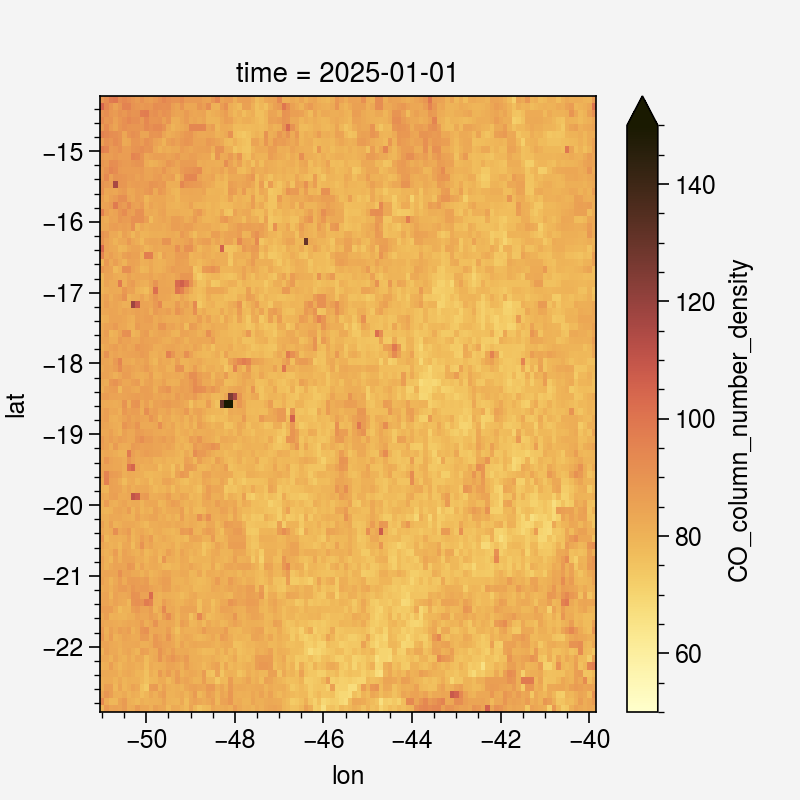

In [9]:
%%time
ds_co_mensal['CO_column_number_density'][0,:,:].plot(cmap='lajolla', vmin=50, vmax=150)

CPU times: user 152 ms, sys: 13.2 ms, total: 165 ms
Wall time: 24.2 s


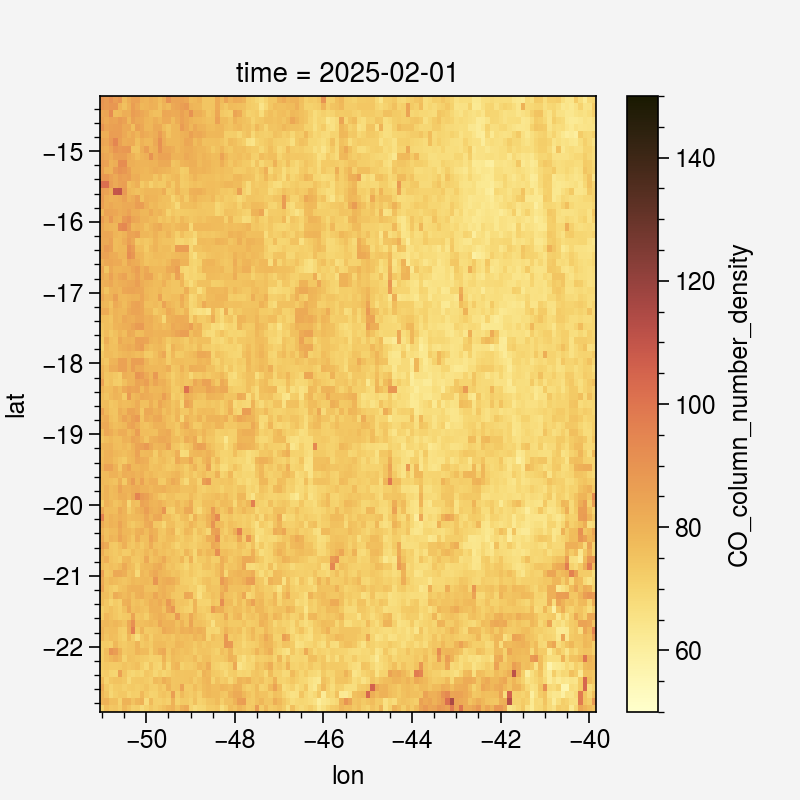

In [10]:
%%time
ds_co_mensal['CO_column_number_density'][1,:,:].plot(cmap='lajolla', vmin=50, vmax=150)

In [ ]:
%%time
ds_co_mensal['CO_column_number_density'][2,:,:].plot(cmap='lajolla', vmin=50, vmax=150)